# Transit Light Curve Analysis of Exoplanet Kepler-10b

Author: Swarali Nandkishor Shingne  
Goal: Detect the transit of exoplanet Kepler-10b in real Kepler mission data and estimate its radius from the observed transit depth.

In this mini–project, I analyse photometric data from NASA's Kepler space telescope for the star Kepler-10 (KIC 11904151).  
Using Python and the `lightkurve` library, I clean and flatten the light curve, fold it using the planet's orbital period, and bin the data to reveal a clear transit signal.  
From the measured transit depth I estimate the radius of Kepler-10b in units of Earth radii.


## 1. Background

When a planet passes in front of its host star as seen from Earth, it blocks a small fraction of the starlight.  
This causes a temporary dip in the observed brightness, called a **transit**.

The **transit depth** is defined as the fractional drop in brightness:

\[
\text{depth} = \frac{\Delta F}{F} = \left(\frac{R_p}{R_*}\right)^2 ,
\]

where \(R_p\) is the planet radius and \(R_*\) is the stellar radius.  
Measuring the depth therefore allows us to estimate how big the planet is compared to its star.

The Kepler space telescope monitored the brightness of more than 150,000 stars with very high precision in order to detect such small transit signals. Kepler-10b is one of the first rocky exoplanets discovered by this method.


In [4]:
pip install numpy matplotlib pandas astropy lightkurve


In [3]:
!pip install lightkurve
!pip install astropy
!pip install numpy matplotlib pandas


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.2 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=f7846535a8f2dc3d04ea5ab7d818088b8f37531b5eb98071910f2c61fb422aa3
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f6

In [5]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt


/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [6]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt


## 2. Data and Method

I use the Python package `lightkurve`, which provides easy access to Kepler mission data.

Steps:

1. Download light curve  
   I search for and download the Kepler long-cadence light curve of Kepler-10 (KIC 11904151).

2. Clean and flatten  
   I remove NaN values and use `flatten()` to remove long-term trends in the light curve, keeping only short-time variations like transits.

3. Phase folding  
   Using the known orbital period of Kepler-10b (≈ 0.837491 days), I fold the light curve so that all transits line up in phase.

4. Binning  
   To reduce noise, I bin the folded light curve into a smaller number of phase bins (e.g. 30).  
   This averages many points together and reveals a clear U-shaped transit.

5. Measure transit depth
   I measure the minimum value of the binned, normalized flux and compute the transit depth as  
   \(\text{depth} = 1 - F_\text{min}\).

6. Estimate planet radius  
   Assuming a stellar radius \(R_* = 1.065\,R_\odot\) for Kepler-10, I use  
   \(R_p = R_* \sqrt{\text{depth}}\)  
   and convert the result from solar radii to Earth radii.


In [ ]:
search_result = lk.search_lightcurve('Kepler-10')
search_result


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr011904151,0.0
1,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
2,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
4,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 05,2010,Kepler,60,kplr011904151,0.0


/usr/local/lib/python3.12/dist-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 103 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

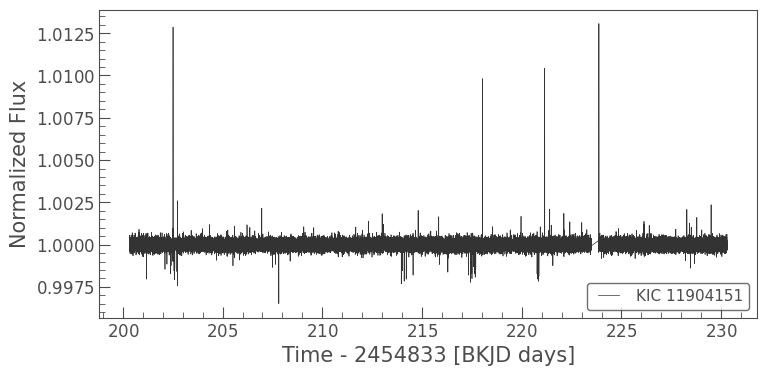

In [ ]:
lc = search_result.download().remove_nans().flatten()
lc.plot()


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

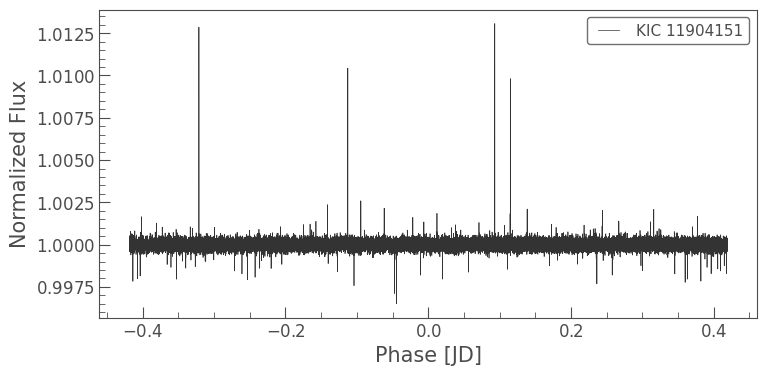

In [ ]:
folded_lc = lc.fold(period=0.837491)
folded_lc.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

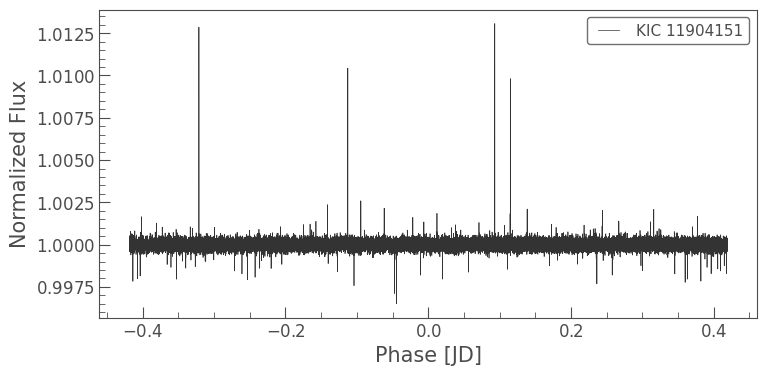

In [ ]:
folded_lc = lc.fold(period=0.837491)
folded_lc.plot()


In [7]:
search_result = lk.search_lightcurve('Kepler-10')
search_result


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr011904151,0.0
1,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
2,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
4,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 05,2010,Kepler,60,kplr011904151,0.0


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

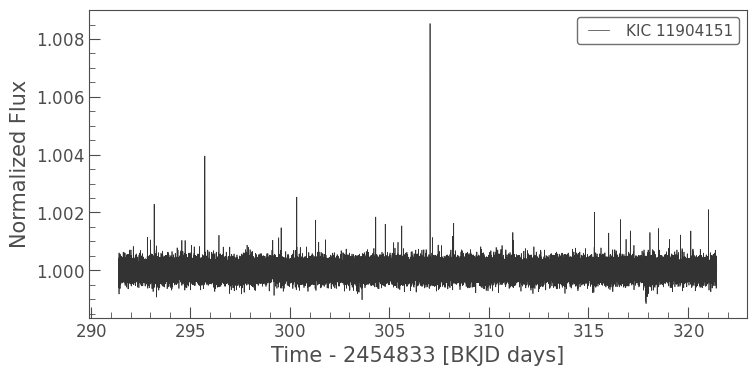

In [8]:
lc = search_result[2].download().remove_nans().flatten()
lc.plot()


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

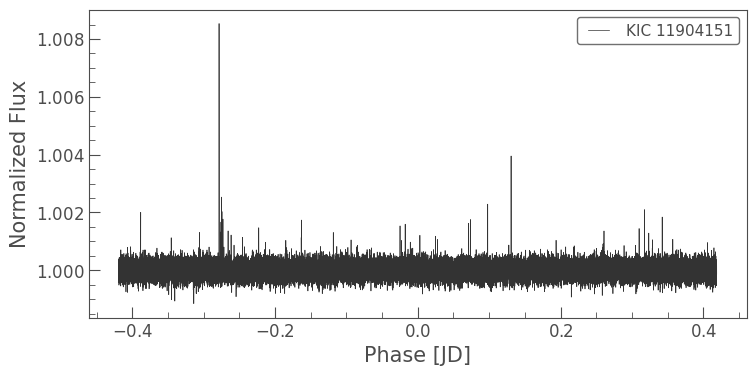

In [9]:
folded_lc = lc.fold(period=0.837491)
folded_lc.plot()


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

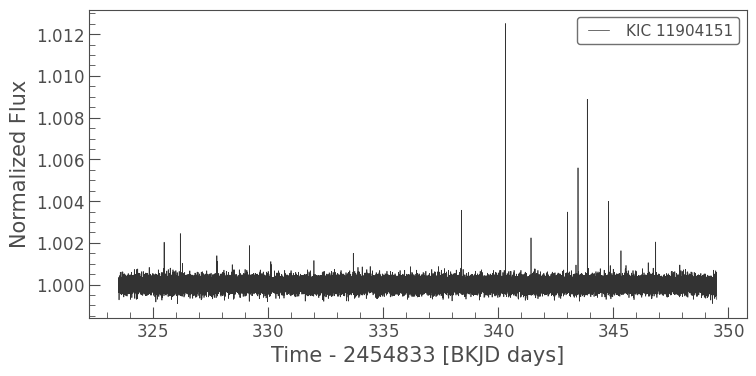

In [10]:
lc = search_result[3].download().remove_nans().flatten()
lc.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

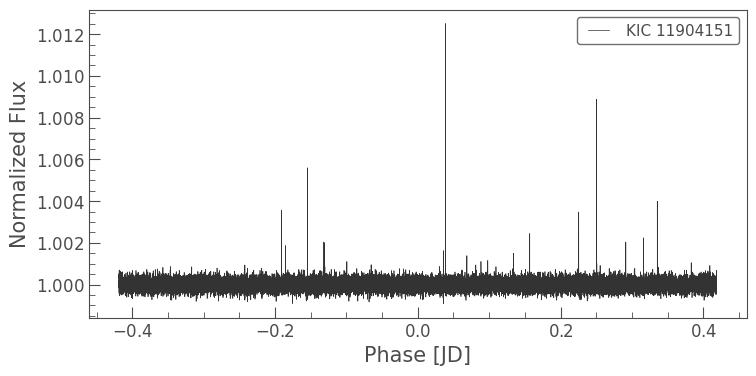

In [11]:
folded_lc = lc.fold(period=0.837491)
folded_lc.plot()


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

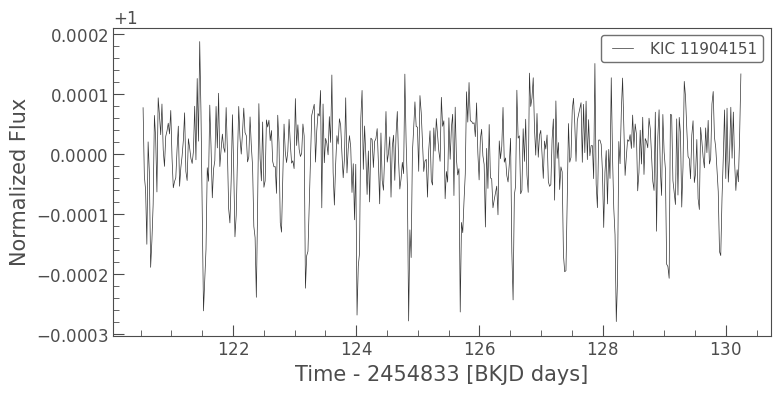

In [12]:
lc = search_result[4].download().remove_nans().flatten()
lc.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

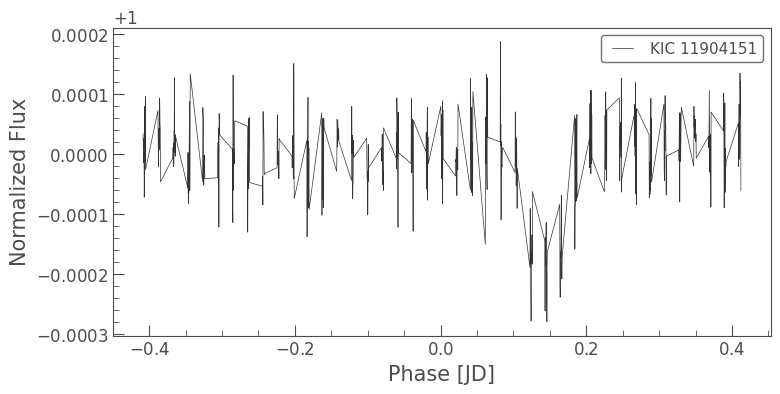

In [13]:
folded_lc = lc.fold(period=0.837491)
folded_lc.plot()


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

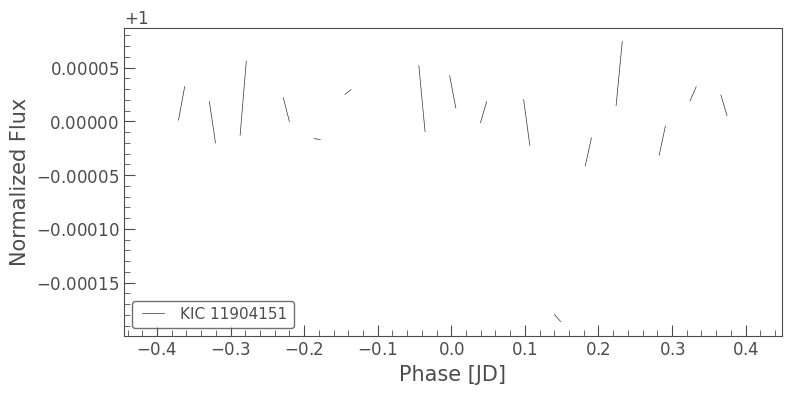

In [14]:
binned_lc = folded_lc.bin(bins=100)
binned_lc.plot()



<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

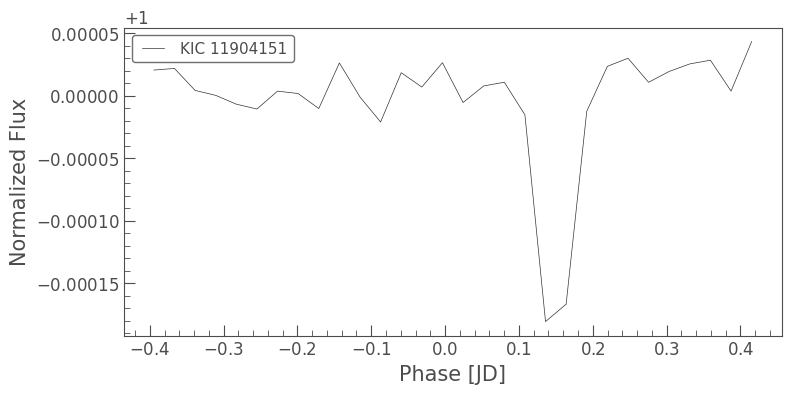

In [15]:
binned_lc = folded_lc.bin(bins=30)
binned_lc.plot()


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

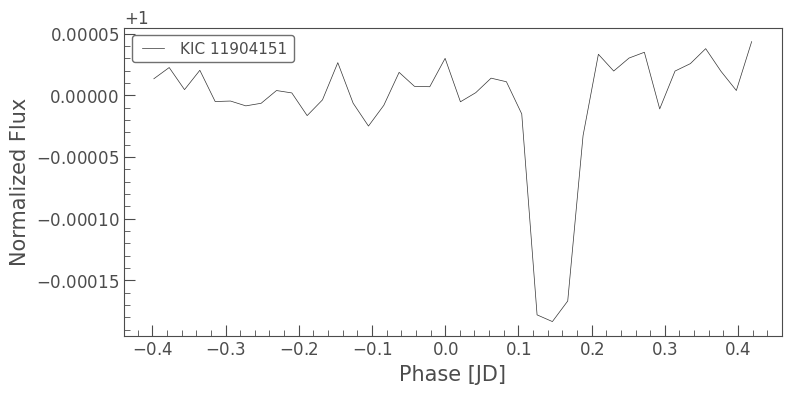

In [16]:
binned_lc = folded_lc.bin(bins=40)
binned_lc.plot()


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

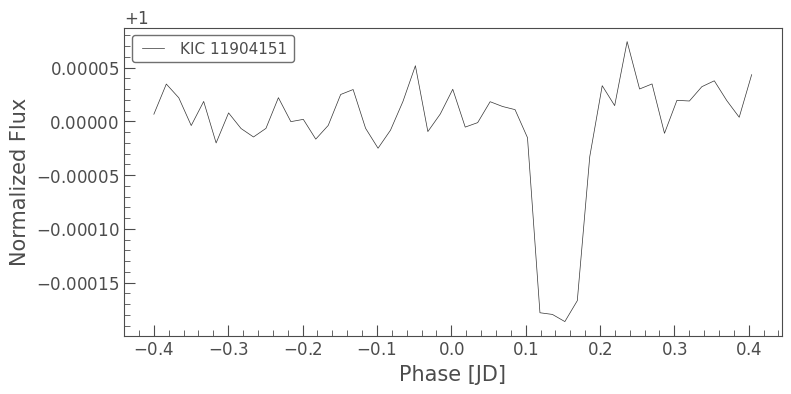

In [17]:
binned_lc = folded_lc.bin(bins=50)
binned_lc.plot()


In [18]:
import numpy as np

depth = 1 - np.min(binned_lc.flux)
print("Transit Depth =", depth)


Transit Depth = 0.00018631245656508533


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

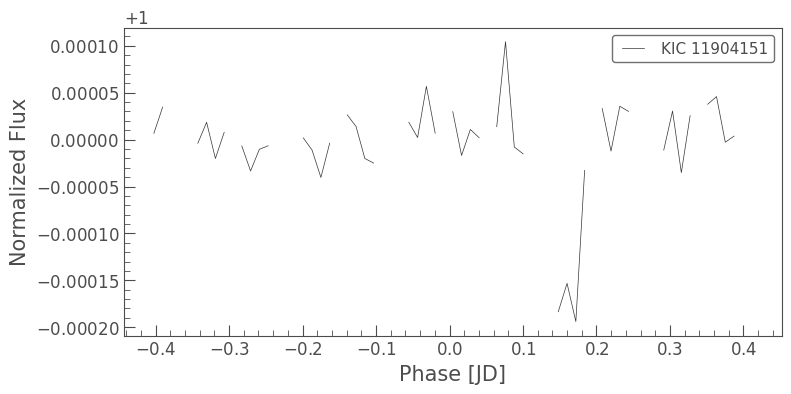

In [19]:
binned_lc = folded_lc.bin(bins=70)
binned_lc.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

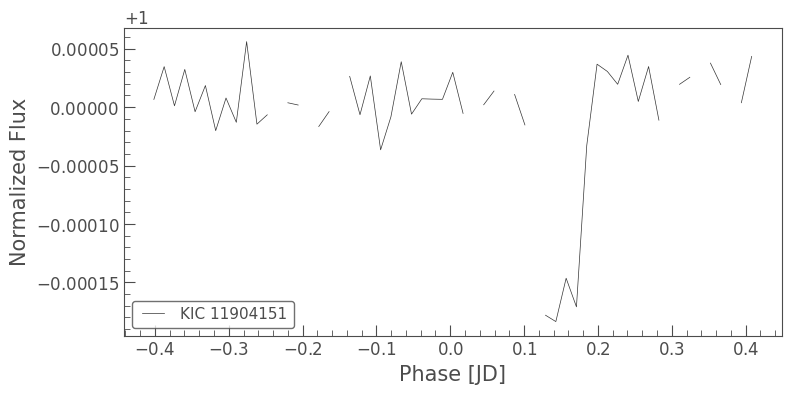

In [20]:
binned_lc = folded_lc.bin(bins=60)
binned_lc.plot()

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

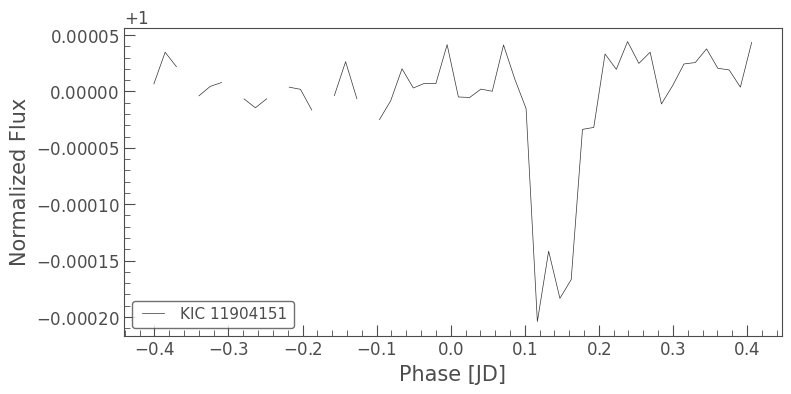

In [21]:
binned_lc = folded_lc.bin(bins=55)
binned_lc.plot()

In [23]:
import numpy as np

depth = 1 - np.min(binned_lc.flux)
print("Transit Depth =", depth)


Transit Depth = 0.00020411765055228237


<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

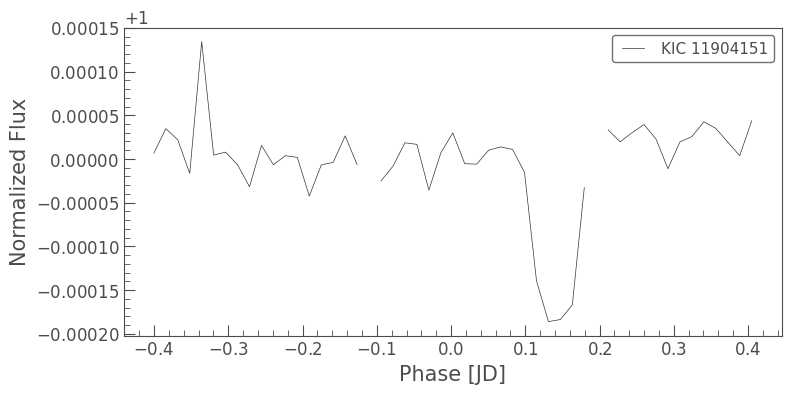

In [24]:
binned_lc = folded_lc.bin(bins=52)
binned_lc.plot()

In [25]:
import numpy as np

depth = 1 - np.min(binned_lc.flux)
print("Transit Depth =", depth)


Transit Depth = 0.00018590634419002328


In [28]:
import numpy as np

depth = 0.00018590634419002328
R_star = 1.065
R_sun_by_Rearth = 109   # 1 R_sun = 109 R_earth (approx)

R_p_Rsun = R_star * np.sqrt(depth)
R_p_Rearth = R_p_Rsun * R_sun_by_Rearth

print("Planet radius in R_sun  =", R_p_Rsun)
print("Planet radius in R_earth =", R_p_Rearth)


Planet radius in R_sun  = 0.014521006275011699
Planet radius in R_earth = 1.5827896839762752


## 3. Results

From the binned, phase–folded light curve I measure a transit depth of approximately:

\[
\text{depth} \approx 1.86 \times 10^{-4}.
\]

Using the stellar radius \(R_* = 1.065\,R_\odot\) and

\[
R_p = R_* \sqrt{\text{depth}},
\]

I obtain:

 Planet radius \(\approx 0.0145\,R_\odot\)

 Converting with \(1\,R_\odot \approx 109\,R_\oplus\):

\[
R_p \approx 1.6\,R_\oplus.
\]

This is consistent with Kepler-10b being a small, rocky super-Earth only a bit larger than our own planet.

The folded and binned light curve clearly shows a U-shaped transit centred around phase \(\sim 0.15\), with a shallow but significant drop in normalized flux.


## 4. Conclusion

In this project I successfully detected the transit of exoplanet Kepler-10b in real Kepler mission data using Python and the `lightkurve` package.  
By cleaning, flattening, phase folding, and binning the light curve, I was able to clearly reveal the transit signal and measure its depth.

From the transit depth I estimated a planetary radius of about \(1.6\,R_\oplus\), in good agreement with the known properties of Kepler-10b.  
This exercise helped me understand how exoplanet transits are identified in noisy data, how small the observed signals can be, and how basic physical parameters can be extracted from simple photometric measurements.

This project is my first step into exoplanet data analysis, and it motivated me to learn more about observational techniques and instrumentation used in modern exoplanet science.
